# Deep Learning Autoencoder for Anomaly Detection
This notebook implements a PyTorch Autoencoder to detect fraudulent credit card transactions.
Unlike supervised models (like XGBoost), this Autoencoder is trained **only on normal (non-fraudulent) transactions**.
It learns to reconstruct normal data. When a fraudulent transaction is passed through the network, it will have a higher **reconstruction error**, which we use as an anomaly score.


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import joblib

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)


## 1. Load Data & Scalers
We load the dataset and the scalers we saved from the previous EDA phase.

In [2]:
df = pd.read_csv('../data/creditcard.csv')

# Load scalers
scaler_time = joblib.load('../models/scaler_time.pkl')
scaler_amount = joblib.load('../models/scaler_amount.pkl')

# Scale the data
df['Time_scaled'] = scaler_time.transform(df['Time'].values.reshape(-1, 1))
df['Amount_scaled'] = scaler_amount.transform(df['Amount'].values.reshape(-1, 1))

# Drop original Time and Amount
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Reorder columns to match our expected format (Amount, Time, V1...V28, Class)
cols = ['Amount_scaled', 'Time_scaled'] + [f'V{i}' for i in range(1, 29)] + ['Class']
df = df[cols]

# We only train on NORMAL transactions (Class == 0)
normal_data = df[df['Class'] == 0].drop('Class', axis=1).values
fraud_data = df[df['Class'] == 1].drop('Class', axis=1).values

print(f"Normal transactions for training: {normal_data.shape[0]}")


Normal transactions for training: 284315


## 2. Prepare PyTorch Tensors
We convert our numpy arrays to PyTorch tensors and create DataLoaders.

In [3]:
# Convert to PyTorch tensors
X_normal = torch.FloatTensor(normal_data)

# Create DataLoader for batching
batch_size = 256
train_dataset = TensorDataset(X_normal, X_normal) # Target is the same as input
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


## 3. Define Autoencoder Architecture
We define a symmetrical architecture. The encoder compresses the 30 features down to a smaller latent space (e.g., 14), and the decoder tries to reconstruct the 30 features.

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 24),
            nn.Tanh(),
            nn.Linear(24, 14),
            nn.Tanh(),
            nn.Linear(14, 7),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(7, 14),
            nn.Tanh(),
            nn.Linear(14, 24),
            nn.Tanh(),
            nn.Linear(24, input_dim),
            nn.Identity() # Linear output
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

input_dim = X_normal.shape[1]
model = Autoencoder(input_dim)
print(model)


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=24, bias=True)
    (1): Tanh()
    (2): Linear(in_features=24, out_features=14, bias=True)
    (3): Tanh()
    (4): Linear(in_features=14, out_features=7, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=7, out_features=14, bias=True)
    (1): Tanh()
    (2): Linear(in_features=14, out_features=24, bias=True)
    (3): Tanh()
    (4): Linear(in_features=24, out_features=30, bias=True)
    (5): Identity()
  )
)


## 4. Train the Model

Epoch [1/10], Loss: 0.670572


Epoch [2/10], Loss: 0.469297


Epoch [3/10], Loss: 0.405584


Epoch [4/10], Loss: 0.357753


Epoch [5/10], Loss: 0.327749


Epoch [6/10], Loss: 0.311838


Epoch [7/10], Loss: 0.301800


Epoch [8/10], Loss: 0.293456


Epoch [9/10], Loss: 0.286857


Epoch [10/10], Loss: 0.281708


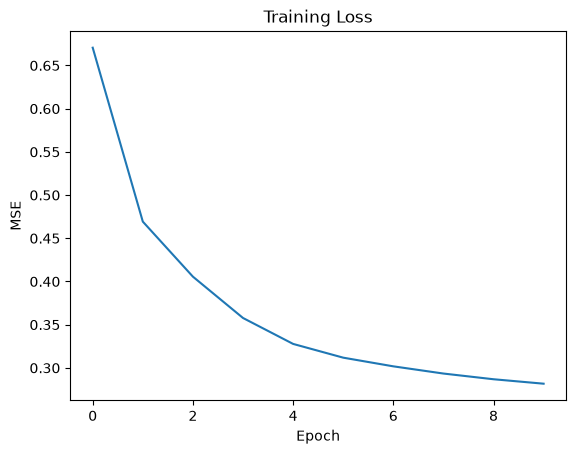

In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10 # Keep small for demonstration, normally would be 50-100
losses = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_features, _ in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_features)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.show()


## 5. Evaluate Reconstruction Error
Let's see how the model performs on normal data vs fraud data.

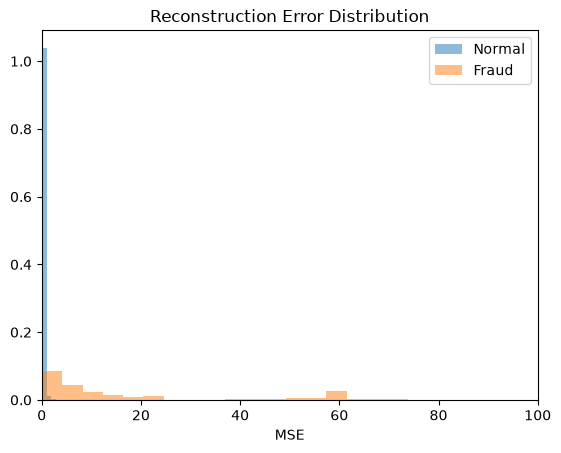

Suggested Anomaly Threshold (95th percentile): 0.6490


In [6]:
model.eval()

with torch.no_grad():
    # Normal data error
    X_normal_sample = X_normal[:5000] # Take a sample
    reconstructed_normal = model(X_normal_sample)
    mse_normal = torch.mean((X_normal_sample - reconstructed_normal)**2, dim=1).numpy()
    
    # Fraud data error
    X_fraud = torch.FloatTensor(fraud_data)
    reconstructed_fraud = model(X_fraud)
    mse_fraud = torch.mean((X_fraud - reconstructed_fraud)**2, dim=1).numpy()

plt.hist(mse_normal, bins=50, alpha=0.5, label='Normal', density=True)
plt.hist(mse_fraud, bins=50, alpha=0.5, label='Fraud', density=True)
plt.title('Reconstruction Error Distribution')
plt.xlabel('MSE')
plt.legend()
plt.xlim(0, 100) # clip for better view
plt.show()

# Calculate threshold based on normal data (e.g., 95th percentile)
threshold = np.percentile(mse_normal, 95)
print(f"Suggested Anomaly Threshold (95th percentile): {threshold:.4f}")


## 6. Save the Model

In [7]:
torch.save(model.state_dict(), '../models/autoencoder.pth')
print("Autoencoder model saved successfully!")


Autoencoder model saved successfully!
